# Игры с цифрами датасета sklearn

Распознать изображения рукописных цифр 

8x8 пикселей

[Recognizing hand-written digits](https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html#recognizing-hand-written-digits)

[Датасеты](https://scikit-learn.org/stable/datasets/toy_dataset.htm)

In [1]:
import matplotlib.pyplot as plt

# Import datasets, classifiers and performance metrics
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split

## Датасет

- digits.images 8x8 arrays of grayscale values for each image
- digits.target подписи

In [2]:
digits = datasets.load_digits()
print(digits['DESCR'])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

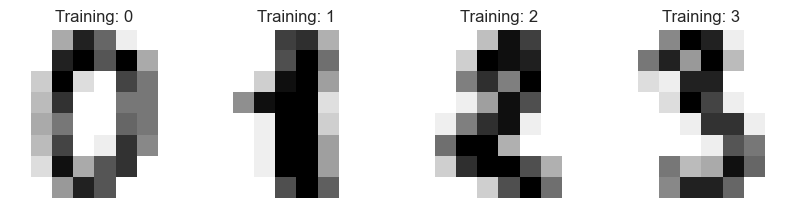

In [3]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Training: {label}")

## Классификация

Превратим каждый двумерный имидж 8x8 в плоский набор из 64 признаков 

In [4]:
n_samples = len(digits.images)  # 1797
data = digits.images.reshape((n_samples, -1))
data.shape

(1797, 64)

Создадим классификатор support vector classifier [SVC](https://scikit-learn.org/stable/modules/svm.html#svc)

In [5]:
clf = svm.SVC(gamma=0.001)

Разобьем выборку на тренировочную и тестовую, 50/50. Указав `shuffle=True`, значения будут перемешиваться перед разделением. Можно задать `random_state`

[3.1. Cross-validation: evaluating estimator performance](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance)

[train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#train-test-split)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.5, shuffle=False)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape, data.shape)

(898, 64) (899, 64) (898,) (899,) (1797, 64)


Обучим модель классификатора на тренировочной выборке

In [7]:
clf.fit(X_train, y_train)

SVC(gamma=0.001)

На основе нашей натренированной модели вычислим (предскажем) значения для тестовой выборки

In [8]:
predicted = clf.predict(X_test)

Выведем первые 4 цифры из тестового набора и подпишем их предсказанными значениями

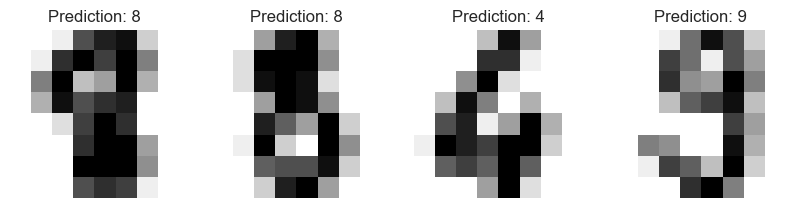

In [9]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction}")

## Оценка результатов и качества классификации

### classification_report

[classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#sklearn.metrics.classification_report) создает текстовый отчет, который показывает главные метрики классификации

[Classification report](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report)

Можно выводить отчет не для всех меток, а только для указанных

```
metrics.classification_report(y_test, predicted, labels=['1', '2'])
```

Метрики:

1. **Precision** (точность): Доля правильно предсказанных положительных наблюдений среди всех предсказанных положительных наблюдений. Формула: TP / (TP + FP), где TP - истинные положительные, FP - ложные положительные.
2. **Recall** (полнота): Доля правильно предсказанных положительных наблюдений среди всех реальных положительных наблюдений. Формула: TP / (TP + FN), где FN - ложные отрицательные.
3. **F1-score**: Средневзвешенное значение точности и полноты, которое помогает найти баланс между этими двумя метриками. Формула: 2 * (Precision * Recall) / (Precision + Recall).
4. **Support** (поддержка): Количество истинных наблюдений в каждом классе.

### accuracy (точность)

[accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#accuracy-score)

YT [ACCURACY | МЕТРИКИ КЛАССИФИКАЦИИ В МАШИННОМ ОБУЧЕНИИ](https://www.youtube.com/watch?v=CCH-1gJo_z0)

Доля правильных ответов. Общее количество правильных предсказаний, деленное на общее количество предсказаний. От *0* (нет правильных ответов, все очень плохо) до *1* (все ответы правильные)

Плохо работает на моделях с дисбалансом классов, когда объектов одного класса намного больше чем другого. Если модель *всегда* будет выдавать класс, который доминирует, то доля правильных ответов будет очень высокой.

### macro avg
Среднее арифметическое всех метрик для каждого класса.

### weighted avg
Средневзвешенное значение всех метрик, где весом является количество наблюдений каждого класса.

YT: [PRECISION, RECALL, CONFUSION MATRIX, ТОЧНОСТЬ, ПОЛНОТА, МАТРИЦА ОШИБОК | МЕТРИКИ КЛАССИФИКАЦИИ](https://www.youtube.com/watch?v=AfnBHL832Eg)

In [10]:
print(
    f"Classification report for classifier {clf}:\n"
    f"{metrics.classification_report(y_test, predicted)}\n"
)

Classification report for classifier SVC(gamma=0.001):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899




### Confusion matrix, матрица неточности

Матрица истинных и предсказанных значений

[Confusion matrix](https://scikit-learn.org/stable/modules/model_evaluation.html#confusion-matrix)

[Wiki](https://en.wikipedia.org/wiki/Confusion_matrix)  

[confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#confusion-matrix)

истинные классы x предсказания. Размер по количеству классов. По диагонали - верные предсказания классификатора. 

По матрице можно определить **точность** по каждому классу как отношение истинного предсказания (диагональ) к сумме предсказаний по классу - сумма столбца класса. Если делить на сумму истинных значений, по получим метрику **полноты**

 

Confusion matrix:
[[87  0  0  0  1  0  0  0  0  0]
 [ 0 88  1  0  0  0  0  0  1  1]
 [ 0  0 85  1  0  0  0  0  0  0]
 [ 0  0  0 79  0  3  0  4  5  0]
 [ 0  0  0  0 88  0  0  0  0  4]
 [ 0  0  0  0  0 88  1  0  0  2]
 [ 0  1  0  0  0  0 90  0  0  0]
 [ 0  0  0  0  0  1  0 88  0  0]
 [ 0  0  0  0  0  0  0  0 88  0]
 [ 0  0  0  1  0  1  0  0  0 90]]


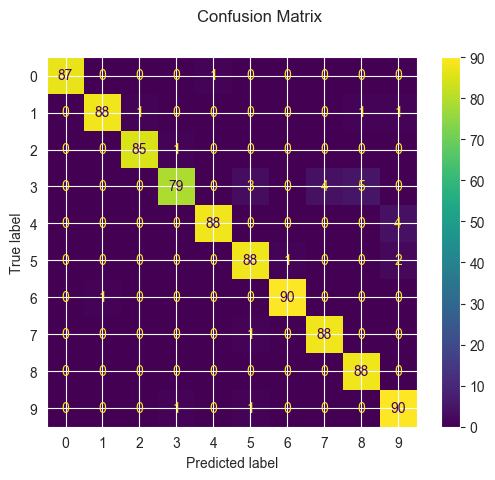

In [11]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, predicted)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()